# BeforeIT analysys

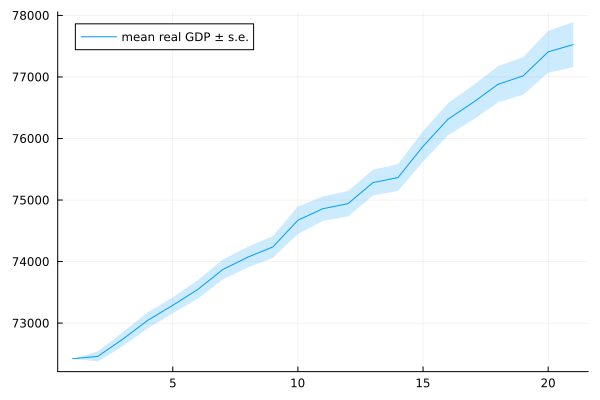

In [21]:
import BeforeIT as Bit
using Plots, Statistics, Random

parameters = Bit.AUSTRIA2010Q1.parameters
initial_conditions = Bit.AUSTRIA2010Q1.initial_conditions

T, n_sims = 20, 32
base = Bit.Model(parameters, initial_conditions)
models = Bit.ensemblerun!([deepcopy(base) for _ in 1:n_sims], T)
dv = Bit.DataVector(models)          # fields become T × n_sims matrices

g = dv.real_gdp
m, s = mean(g, dims=2), std(g, dims=2) ./ sqrt(n_sims)
plot(m, ribbon=s, fillalpha=0.2, label="mean real GDP ± s.e.")

In [11]:
using DataFrames
using CSV

function to_dataframe(dv)
    n_periods, n_sims = size(dv.collection_time)

    df = DataFrame(
        simulation = repeat(1:n_sims, inner = n_periods),
        time = vec(dv.collection_time),
    )

    for name in fieldnames(Bit.Data)
        name == :collection_time && continue

        values = getproperty(dv, name)

        # Inclui apenas séries escalares; dados setoriais são aninhados.
        eltype(values) <: Number || continue

        df[!, name] = vec(values)
    end

    return df
end

to_dataframe (generic function with 1 method)

In [ ]:
df = to_dataframe(dv)

Row,simulation,time,nominal_gdp,real_gdp,nominal_gva,real_gva,nominal_household_consumption,real_household_consumption,nominal_government_consumption,real_government_consumption,nominal_capitalformation,real_capitalformation,nominal_fixed_capitalformation,real_fixed_capitalformation,nominal_fixed_capitalformation_dwellings,real_fixed_capitalformation_dwellings,nominal_exports,real_exports,nominal_imports,real_imports,operating_surplus,compensation_employees,wages,taxes_production,gdp_deflator_growth_ea,real_gdp_ea,euribor
,Int64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,1,1,72422.0,72422.0,64900.9,64900.9,40512.9,40512.9,14866.9,14866.9,15944.2,15944.2,15944.2,15944.2,3173.23,3173.23,34195.6,34195.6,33097.6,33097.6,29576.1,34346.7,28335.3,978.062,0.00193832,2.35485e6,0.00164593
2,1,2,72945.3,72475.9,65371.8,64951.1,40802.1,40539.5,14791.4,14696.2,16244.6,16140.0,16056.1,15952.8,3192.44,3171.9,34588.0,34365.4,33480.8,33265.3,29790.8,34595.9,28540.9,985.159,0.00373735,2.34316e6,0.00112153
3,1,3,73919.6,73068.9,66247.5,65485.1,41335.9,40860.2,15063.6,14890.3,16311.7,16124.0,16278.0,16090.7,3237.39,3200.14,35550.5,35141.4,34342.2,33947.0,30219.0,35030.5,28899.4,998.057,0.00198496,2.37131e6,0.00226606
4,1,4,75125.1,74107.9,67354.4,66442.5,41829.4,41263.1,15227.1,15020.9,16728.4,16501.9,16529.9,16306.1,3276.26,3231.9,35432.3,34952.6,34092.2,33630.6,30713.2,35626.6,29391.2,1014.58,0.00710847,2.37104e6,0.00225002
5,1,5,75159.7,74033.1,67394.1,66383.8,41799.2,41172.6,15226.1,14997.9,16564.8,16316.5,16550.1,16302.0,3278.83,3229.68,35302.0,34772.8,33732.4,33226.7,30742.8,35638.2,29400.7,1013.15,0.00555347,2.37755e6,0.00248111
6,1,6,74428.4,73383.3,66732.6,65795.6,41406.8,40825.4,15339.1,15123.7,16033.8,15808.6,16385.7,16155.6,3239.15,3193.66,36063.4,35557.0,34414.6,33931.4,30448.9,35283.6,29108.2,1000.13,0.00505272,2.38761e6,0.00282926
7,1,7,75775.6,74340.5,67966.3,66679.1,41931.8,41137.6,15593.3,15297.9,16605.3,16290.8,16631.7,16316.7,3263.83,3202.01,36910.0,36210.9,35264.6,34596.7,30941.7,36001.2,29700.3,1023.36,0.00533054,2.4003e6,0.00326518
8,1,8,76966.0,74876.5,69043.8,67169.4,42563.7,41408.2,15669.3,15243.9,17038.8,16576.2,16889.6,16431.1,3309.02,3219.19,36823.7,35824.0,35129.5,34175.8,31446.8,36556.8,30158.6,1040.25,0.00584768,2.38083e6,0.00235949
9,1,9,78102.8,75089.0,70075.8,67371.8,43137.0,41472.5,15982.9,15366.1,17185.7,16522.6,17162.5,16500.3,3364.74,3234.9,36082.2,34689.9,34285.1,32962.1,31948.1,37073.6,30585.0,1054.09,0.00502526,2.37838e6,0.00219915


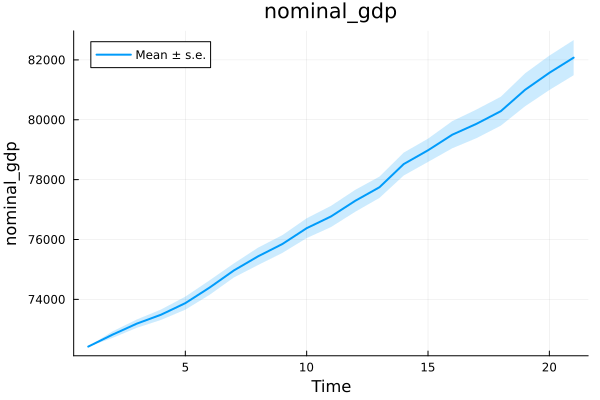

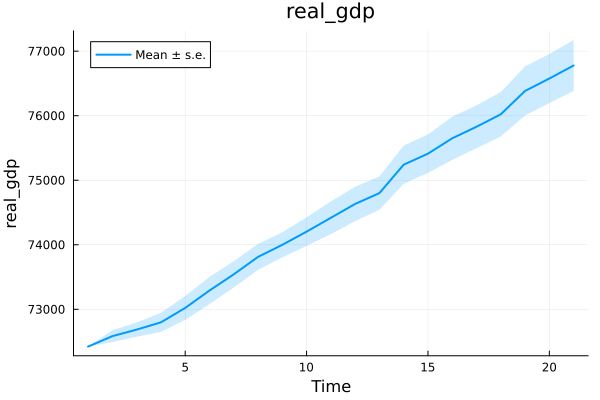

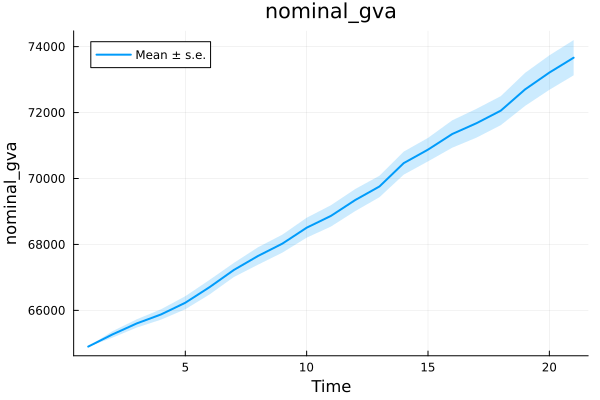

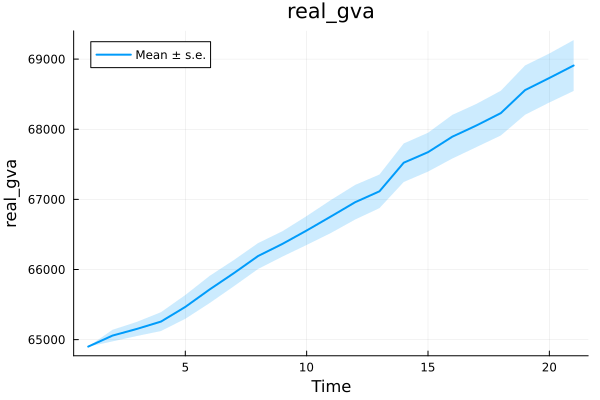

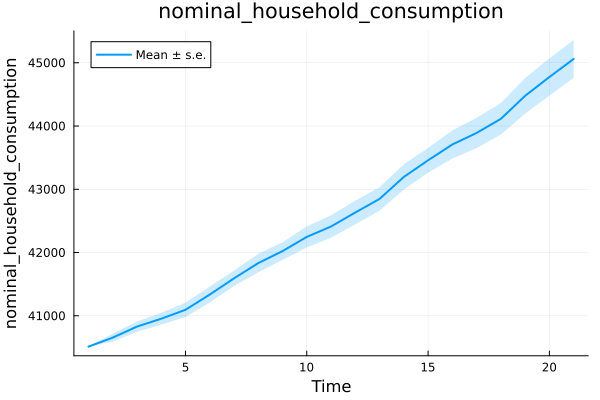

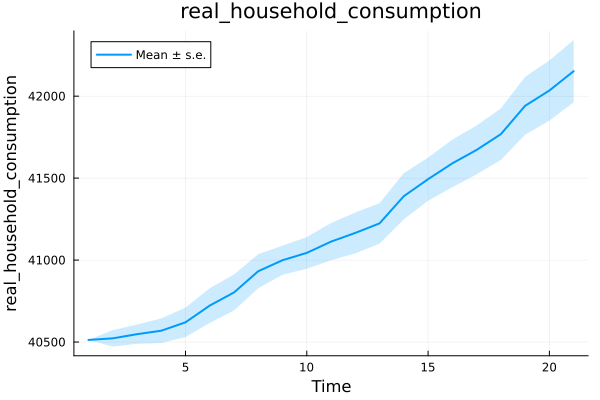

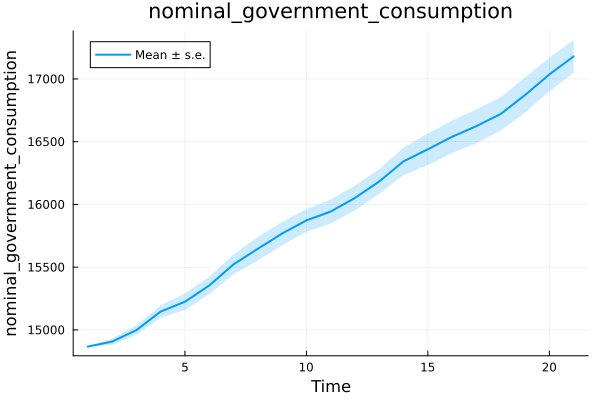

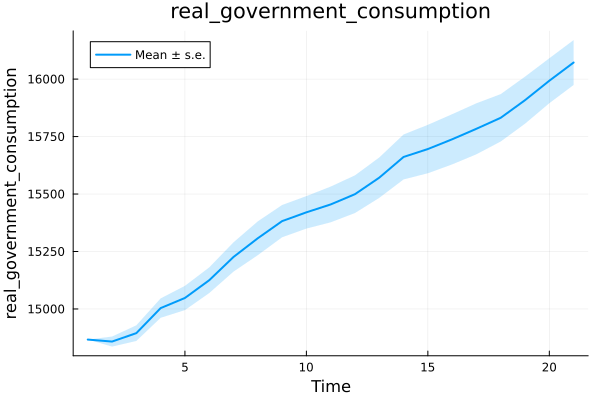

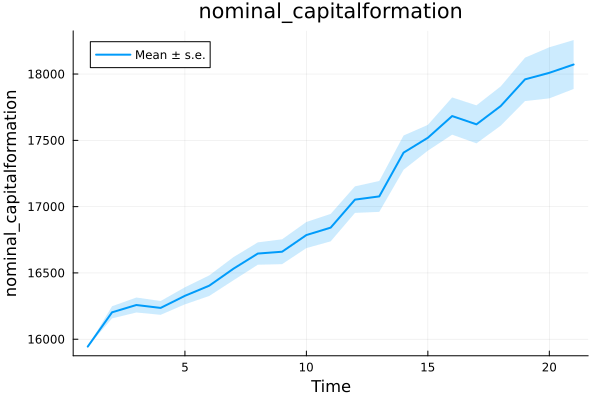

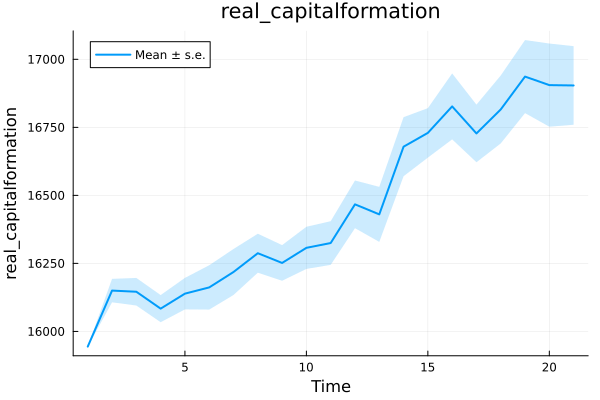

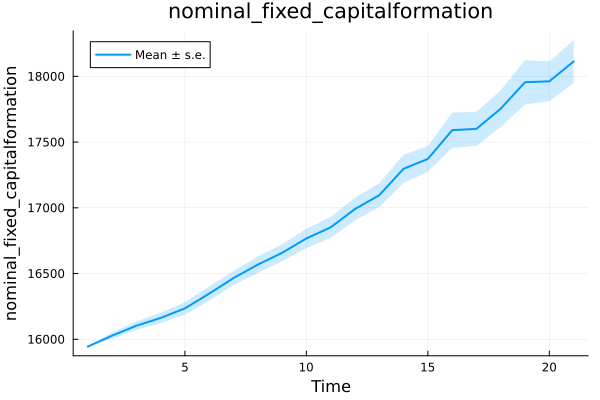

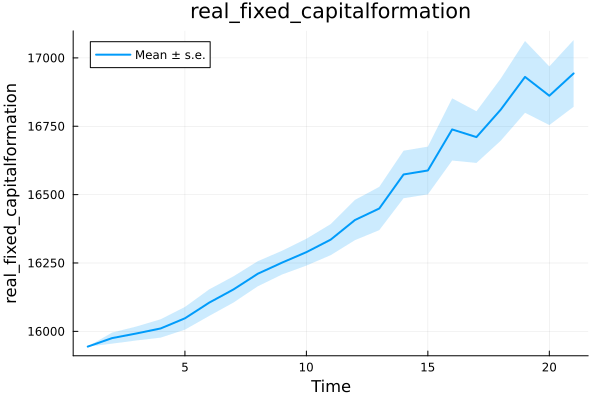

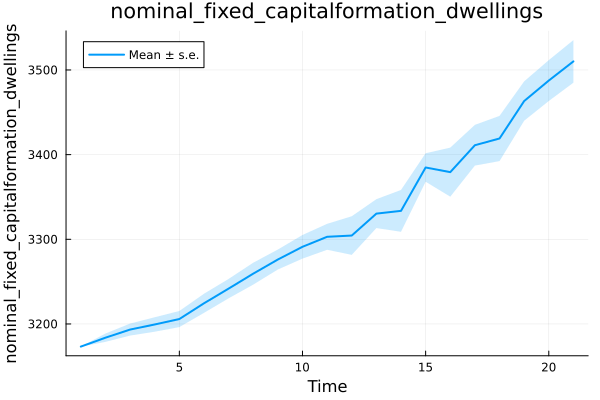

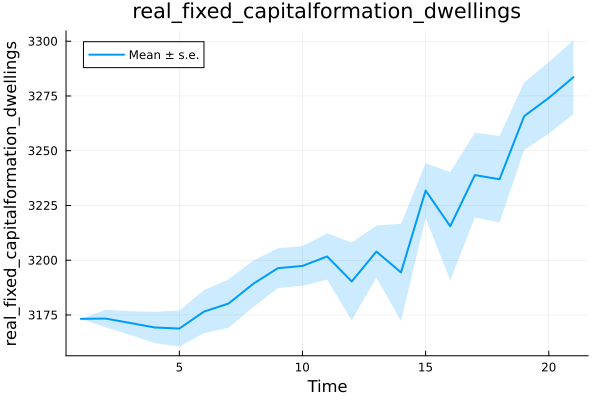

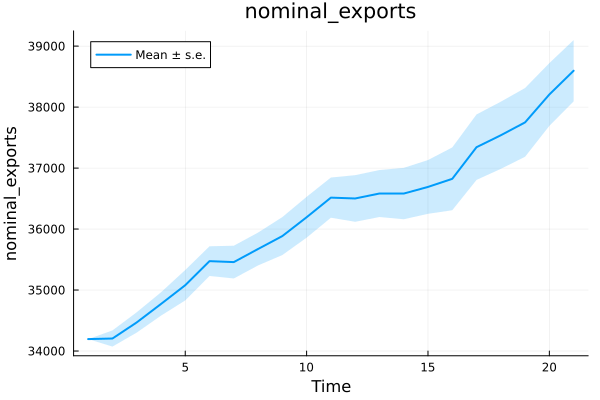

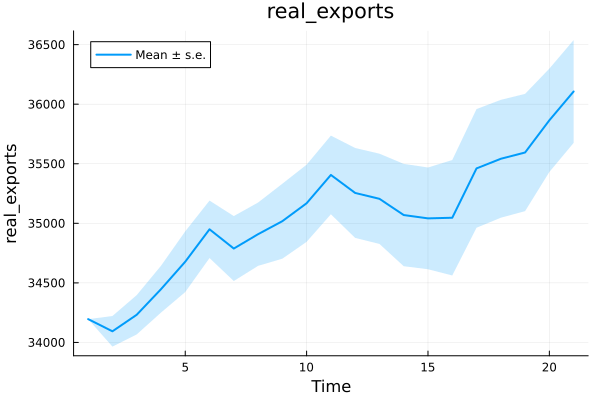

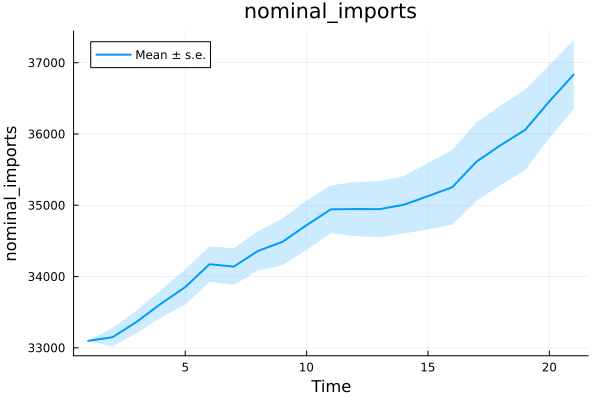

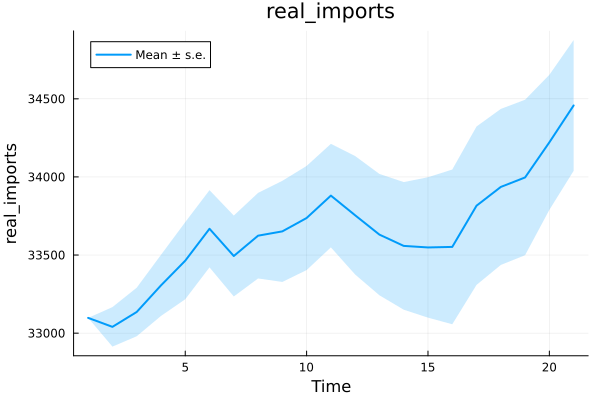

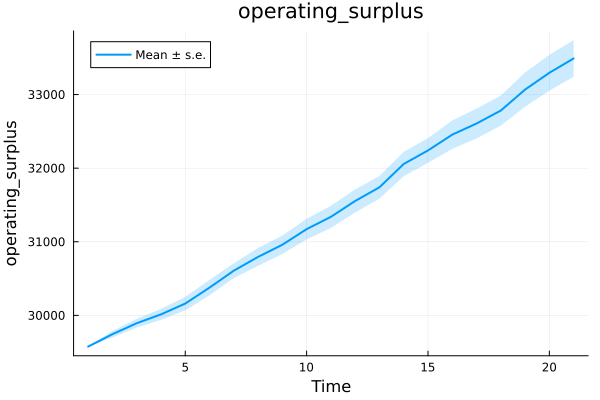

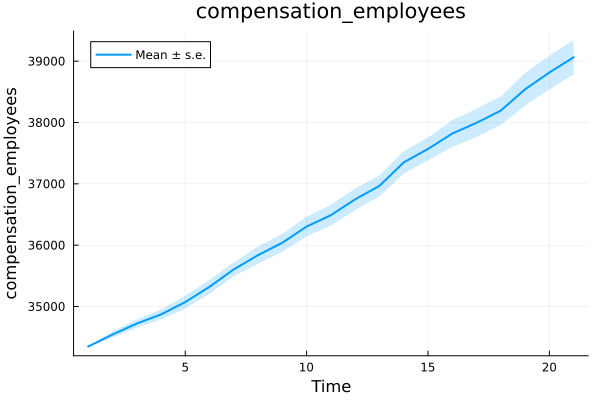

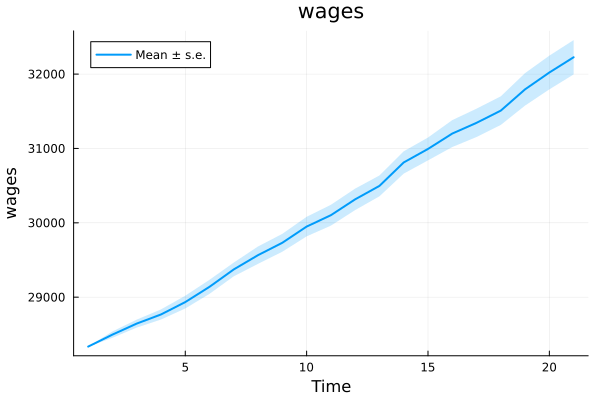

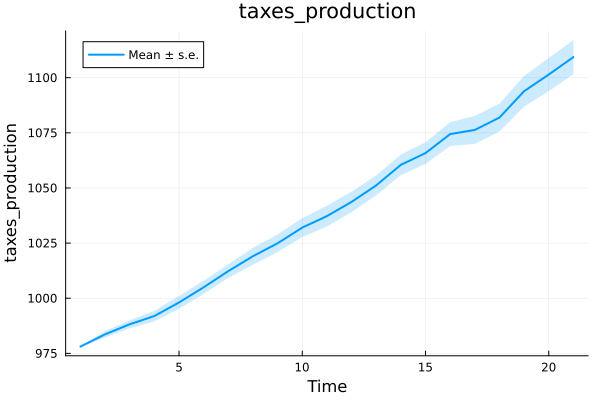

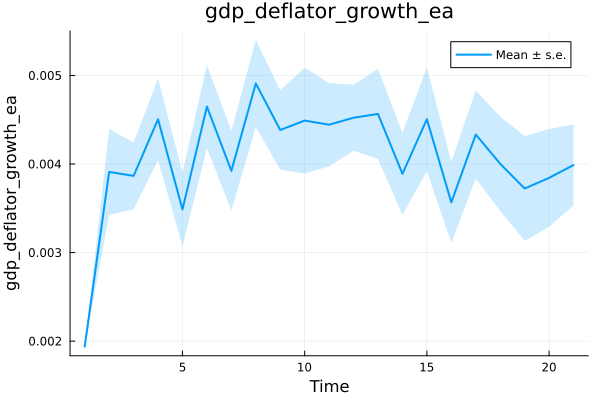

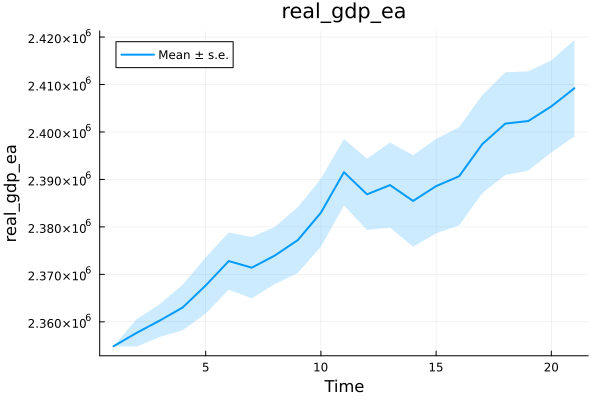

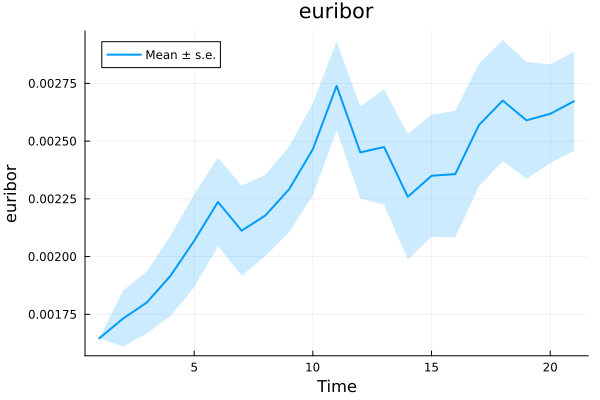

In [22]:
 n_sims = length(unique(df.simulation))

  for name in names(df)
      name in ("time", "simulation") && continue
      eltype(df[!, name]) <: Number || continue

      summary = combine(
          groupby(df, :time),
          name => mean => :average,
          name => std => :standard_deviation,
      )

      sort!(summary, :time)

      standard_error =
          summary.standard_deviation ./ sqrt(n_sims)

      p = plot(
          summary.time,
          summary.average;
          ribbon = standard_error,
          fillalpha = 0.2,
          linewidth = 2,
          label = "Mean ± s.e.",
          title = name,
          xlabel = "Time",
          ylabel = name,
      )

      display(p)

      # Optional:
      # savefig(p, "$(name).png")
  end

true